In [1]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *
import numpy as np

In [2]:
# class ObservableDataset(Dataset):
# 	"""
# 	Converts observable dataset into PyTorch syntax.
# 	"""
# 	def __init__(self, data):
# 		self.data = data

# 	def __len__(self):
# 		return self.data.shape[0]

# 	def __getitem__(self, idx):
# 		sample = self.data[idx]
# 		return sample

In [3]:
# def a_b_c_grid(x_range, y_range, z_range, n_points):
#     """
#     Creates a grid of values within a three-dimensional range and returns it in a flattened tensor.

#     Parameters:
#     x_range (tuple): A tuple of (min, max) for the x-axis range.
#     y_range (tuple): A tuple of (min, max) for the y-axis range.
#     z_range (tuple): A tuple of (min, max) for the z-axis range.
#     steps (int): --- The number of steps/points in each dimension.

#     Returns:
#     torch.Tensor: A flattened tensor containing all the grid points.
#     """
#     # Create linearly spaced points for each range
#     x_points = torch.linspace(x_range[0], x_range[1], n_points)
#     y_points = torch.linspace(y_range[0], y_range[1], n_points)
#     z_points = torch.linspace(z_range[0], z_range[1], n_points)

#     # Create a meshgrid from the x and y points
#     x_grid, y_grid, z_grid = torch.meshgrid(x_points, y_points, z_points, indexing='ij')

#     # Flatten the grid and stack the coordinates
#     grid_flattened = torch.stack([x_grid.flatten(), y_grid.flatten(), z_grid.flatten()], dim=1)

#     return grid_flattened

# def a_b_c_grid_custom(x_points, y_points, z_points):
#     """
#     Creates a grid of values within a three-dimensional range and returns it in a flattened tensor.

#     Parameters:
#     x_points (tuple): An array of points for evaluation for the x-axis range.
#     y_points (tuple): An array of points for evaluation for the y-axis range.
#     z_points (tuple): An array of points for evaluation for the z-axis range.

#     Returns:
#     torch.Tensor: A flattened tensor containing all the grid points.
#     """

#     # Create a meshgrid from the x and y points
#     x_grid, y_grid, z_grid = torch.meshgrid(x_points, y_points, z_points, indexing='ij')

#     # Flatten the grid and stack the coordinates
#     grid_flattened = torch.stack([x_grid.flatten(), y_grid.flatten(), z_grid.flatten()], dim=1)

#     return grid_flattened

In [4]:
# # Paths to the datasets
# # exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.1_aU-0.1_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# # exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD-0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.31_N_1.0e+05_hadrons.npy'
# # exp_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
# # sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# # sim_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# # sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# # sim_accept_reject_PATH = '../data/structured_data/pgun_qqbar_mT2_accept_reject_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# # sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
# # sim_fPrel_PATH         = '../data/structured_data/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'

# # Load the arrays
# exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
# sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
# sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
# sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")

# # Print dataset shapes
# print('Experimental observable shape:', exp_hadrons.shape)
# print('Simulated observable shape:', sim_hadrons.shape)
# print('Simulated z shape:', sim_accept_reject.shape)
# print('Simulated fPrel shape:', sim_fPrel.shape)

# # Restrict to a subset of the full dataset (for memory)
# N_events = int(100000)

# # Extract the hadron multiplicity
# exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])
# sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])

# # Convert into torch objects
# sim_mult          = torch.Tensor(sim_mult[0:N_events].copy())
# sim_accept_reject = torch.Tensor(sim_accept_reject[0:N_events].copy())
# sim_fPrel         = torch.Tensor(sim_fPrel[0:N_events].copy())
# exp_mult          = torch.Tensor(exp_mult[0:N_events].copy())

# # Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
# # The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
# # z = 1, this term diverges to -inf and completely destroys the backward pass.
# epsilon = 1e-5
# sim_accept_reject[sim_accept_reject == 1] = 1 - epsilon

# # Print dataset shapes
# print('Experimental multiplicity shape:', exp_mult.shape)
# print('Simulated multiplicity shape:', sim_mult.shape)
# print('Simulated z shape:', sim_accept_reject.shape) # only has the z values, accepted and rejected
# print('Simulated fPrel shape:', sim_fPrel.shape)

# # Prepare data for DataLoader
# sim_mult          = ObservableDataset(sim_mult)
# sim_accept_reject = ObservableDataset(sim_accept_reject)
# sim_mT            = ObservableDataset(sim_fPrel)
# exp_mult          = ObservableDataset(exp_mult)

In [5]:
# # Set batch size -- set it eqaul to the number of events, we only want one 'batch'
# batch_size = N_events

# # Initialize data-loaders
# sim_observable_dataloader    = DataLoader(sim_mult,          batch_size = batch_size, shuffle = False)
# sim_accept_reject_dataloader = DataLoader(sim_accept_reject, batch_size = batch_size, shuffle = False)
# sim_fPrel_dataloader         = DataLoader(sim_fPrel,         batch_size = batch_size, shuffle = False)
# exp_observable_dataloader    = DataLoader(exp_mult,          batch_size = batch_size, shuffle = False)

In [6]:
# # Training hyperparameters
# over_sample_factor = 10.0
# # The flow map will be dependent on the learning rate (size of the gradients)
# learning_rate = 0.01
# fixed_binning = True
# # Length of event buffer
# dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
# dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

# print('Each event has been zero-padded to a length of', dim_multiplicity)
# print('Each emission has been zero-padded to a length of', dim_accept_reject)

# # Define base parameters of simulated data (a, b)
# # params_base = torch.tensor([0.72, 0.88])

# aExtraDQuark = 0
# aExtraUQuark = 0
# aExtraSQuark = 0
# aExtraCquark = 0
# aExtraBquark = 0
# aExtraDiquark = 0.97

# bNonstandardD = 0.88
# bNonstandardU = 0.88
# bNonstandardS = 0.88
# bNonstandardC = 0.88
# bNonstandardB = 0.88
# bNonstandardH = 0.88

# aLund = 0.68
# bLund = 0.98
# sigma_base = 0.335

# aLundD = aLund + aExtraDQuark
# # bLundD = bNonstandardD
# bLundD = bLund
# aLundU = aLund + aExtraUQuark
# # bLundU = bNonstandardU
# bLundU = bLund
# aLundS = aLund + aExtraSQuark
# # bLundS = bNonstandardS
# bLundS = bLund
# aLundDiquark = aLund + aExtraDiquark
# # bLundDiquark = bNonstandardH
# bLundDiquark = bLund


# # params_base = {'a0': torch.tensor(aLund), 'b0': torch.tensor(bLund),
# params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
#             'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
#             'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
#             'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
#             'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
#             'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
#             'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark),
#             'sigma': torch.tensor(sigma_base)}

# # params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU)}
# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD),'sigma': torch.tensor(sigma_base)}

# # Define a grid of initial parameters
# ad_range  = (0.5-0.1, 1.5+0.1)#(0.6, 0.80)
# au_range  = (0.5-0.1, 1.5+0.1)#(0.6, 0.80)
# bd_range  = (0.6-0.1, 1.6+0.1)#(0.85, 1.05)

# # n_points = 10
# # ad_points  = torch.linspace(0.5-0.1, 1.5+0.1,n_points)#(0.6, 0.80)
# # # au_points  = torch.tensor([0.58])
# # bd_points  = torch.linspace(0.6-0.1, 1.6+0.1, n_points)#(0.85, 1.05)
# # # ad_points  = torch.tensor([0.68])
# # # bd_points  = torch.tensor([0.98])
# # # sigma_points  = torch.tensor([0.285, 0.300, 0.335])
# # # ad_points  = torch.linspace(0.68-0.1, 0.68+0.1, n_points)#(0.6, 0.80)
# # # bd_points  = torch.linspace(0.98-0.1, 0.98+0.1, n_points)#(0.6, 0.80)
# # # sigma_points  = torch.tensor([0.285, 0.300, 0.335])
# # # ad_points  = torch.tensor([0.62,0.63,0.64,0.65,0.66,0.67,0.68])
# # # ad_points  = torch.tensor([0.67,0.68, 0.69,0.70,0.71,0.72,0.73,0.74,0.75,0.76,0.77,0.78,0.79])
# # # bd_points  = torch.tensor([0.87,0.88,0.89,0.90,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99])
# # # sigma_points  = torch.tensor([0.295,0.300,0.305,0.310,0.315,0.320,0.325,0.330,0.335,0.340])
# # sigma_points  = torch.tensor([0.330,0.335,0.340])
# # # b_range = (0.88,1)

# # # Search the whole range of parameters
# # # a_range  = (0.03, 3.0)#(0.6, 0.80)
# # # b_range  = (0.2, 2.0)#(0.85, 1.05)
# # # a_range  = (0.03, 3.0)#(0.6, 0.80)
# # # b_range  = (0.2, 2.0)#(0.85, 1.05)

# # n_points = 6
# # # ad_bd_au_init = a_b_c_grid(ad_range, bd_range, au_range, n_points) #The order need to be the same as the parameters_learn order
# # ad_bd_au_init = a_b_c_grid_custom(ad_points, bd_points, sigma_points) #The order need to be the same as the parameters_learn order

In [7]:
# r_b = torch.tensor([aLundD,bLundD,sigma_base])
# r_t = torch.tensor([0.78,0.88,0.300])
# s = torch.linspace(0,1,5)
# s = s[:, torch.newaxis]
# line_grid = r_b + s*(r_t-r_b)
# line_grid = torch.tensor(line_grid)
# print(line_grid)



In [8]:
# # Irrelevant parameters for the flow plot that must be initialized for the RSA class
# epochs = 1

# # Create an RSA instance
# RSA = RSA_nD_tuner(epochs = epochs, dim_multiplicity = dim_multiplicity, dim_accept_reject = dim_accept_reject, over_sample_factor = over_sample_factor,
# 				params_base = params_base, sim_observable_dataloader = sim_observable_dataloader, sim_z_dataloader = sim_accept_reject_dataloader, 
# 				sim_fPrel_dataloader = sim_fPrel_dataloader, exp_observable_dataloader = exp_observable_dataloader, print_details = False, 
# 				results_dir = "/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flowmap", params_init = params_learn, fixed_binning = True)

In [9]:
# # print(a_b_init)
# # Set the optimizer
# optimizer = torch.optim.Adam(RSA.weight_nexus.parameters(), lr=learning_rate)
# #optimizer = torch.optim.SGD(macroscopic_trainer.weight_nexus.parameters(), lr=learning_rate)
# # Generate gradients
# a_b_gradients, loss_grid, metrics = RSA.RSA_flow(optimizer, line_grid)
# a_b_c = line_grid.detach().numpy()

In [10]:

# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from mpl_toolkits.mplot3d import Axes3D

# #to save:
# # Calculate the magnitude of each vector in a_b_gradients
# magnitudes = np.linalg.norm(a_b_gradients, axis=1)
# print(magnitudes.shape)

# mu = metrics[0]
# Neff = metrics[1]
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/line_mu_1', mu)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/line_Neff_1', Neff)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/line_magnitudes_1',magnitudes)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/line_gradients_1',a_b_gradients)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/line_ad_bd_sig_1',a_b_c)
# np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/line_loss_grid_1',loss_grid)




# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')

# ad = a_b_c[:,0]
# bd = a_b_c[:,1]
# sig = a_b_c[:,2]

# g1,g2,g3 =  -a_b_gradients[:,0], -a_b_gradients[:,1], -a_b_gradients[:,2],
# scale = 10e2
# ax.quiver(ad,bd,sig,g1/scale,g2/scale,g3/scale)
# # sc = ax.scatter(ad, bd, sig, c=magnitudes, cmap='plasma', s=20)  # 's' is size, 'c' is color
# sc = ax.scatter(ad, bd, sig, c=np.log10((loss_grid)), cmap='plasma', s=20)  # 's' is size, 'c' is color
# ax.scatter(0.68,0.98,0.335, label = 'base', c= 'black', s=50)
# ax.scatter(0.78,0.88,0.300, label = 'target', c='red', s=50)


In [11]:
# # Paths to the datasets
# # exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.1_aU-0.1_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# # exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
# # exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD-0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.31_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
# # exp_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
# # sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# # sim_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# # sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# # sim_accept_reject_PATH = '../data/structured_data/pgun_qqbar_mT2_accept_reject_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# # sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
# # sim_fPrel_PATH         = '../data/structured_data/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'

# # Load the arrays
# exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
# sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
# sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
# sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")

# # Print dataset shapes
# print('Experimental observable shape:', exp_hadrons.shape)
# print('Simulated observable shape:', sim_hadrons.shape)
# print('Simulated z shape:', sim_accept_reject.shape)
# print('Simulated fPrel shape:', sim_fPrel.shape)


In [12]:
# # Training hyperparameters
# over_sample_factor = 10.0
# # The flow map will be dependent on the learning rate (size of the gradients)
# learning_rate = 0.01
# fixed_binning = True
# # Length of event buffer
# # dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
# # dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

# # print('Each event has been zero-padded to a length of', dim_multiplicity)
# # print('Each emission has been zero-padded to a length of', dim_accept_reject)

# # Define base parameters of simulated data (a, b)
# # params_base = torch.tensor([0.72, 0.88])

# aExtraDQuark = 0
# aExtraUQuark = 0
# aExtraSQuark = 0
# aExtraCquark = 0
# aExtraBquark = 0
# aExtraDiquark = 0.97

# bNonstandardD = 0.88
# bNonstandardU = 0.88
# bNonstandardS = 0.88
# bNonstandardC = 0.88
# bNonstandardB = 0.88
# bNonstandardH = 0.88

# aLund = 0.68
# bLund = 0.98
# sigma_base = 0.335

# aLundD = aLund + aExtraDQuark
# # bLundD = bNonstandardD
# bLundD = bLund
# aLundU = aLund + aExtraUQuark
# # bLundU = bNonstandardU
# bLundU = bLund
# aLundS = aLund + aExtraSQuark
# # bLundS = bNonstandardS
# bLundS = bLund
# aLundDiquark = aLund + aExtraDiquark
# # bLundDiquark = bNonstandardH
# bLundDiquark = bLund


# # params_base = {'a0': torch.tensor(aLund), 'b0': torch.tensor(bLund),
# params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
#             'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
#             'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
#             'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
#             'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
#             'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
#             'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark),
#             'sigma': torch.tensor(sigma_base)}

# # params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU)}
# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD),'sigma': torch.tensor(sigma_base)}


# r_b = torch.tensor([aLundD,bLundD,sigma_base])
# r_t = torch.tensor([0.78,0.88,0.300])
# s = torch.linspace(0,1,5)
# s = s[:, torch.newaxis]
# line_grid = r_b + s*(r_t-r_b)
# line_grid = torch.tensor(line_grid)


In [13]:
# all_gradients = []
# all_loss_grid = []
# all_metrics_Neff = []
# all_metrics_mu = []

# Ns = [10,50,100]
# repeat = 3
# for N_events in Ns:
#     for n in range(repeat):

#         # Extract the hadron multiplicity
#         exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])
#         sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])
#         # Convert into torch objects
#         sim_mult_t         = torch.Tensor(sim_mult[0:N_events].copy())
#         sim_accept_reject_t = torch.Tensor(sim_accept_reject[0:N_events].copy())
#         sim_fPrel_t         = torch.Tensor(sim_fPrel[0:N_events].copy())
#         exp_mult_t          = torch.Tensor(exp_mult[0:N_events].copy())

#         # Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
#         # The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
#         # z = 1, this term diverges to -inf and completely destroys the backward pass.
#         epsilon = 1e-5
#         sim_accept_reject_t[sim_accept_reject_t == 1] = 1 - epsilon

#         # Print dataset shapes
#         print('Experimental multiplicity shape:', exp_mult_t.shape)
#         print('Simulated multiplicity shape:', sim_mult_t.shape)
#         print('Simulated z shape:', sim_accept_reject_t.shape) # only has the z values, accepted and rejected
#         print('Simulated fPrel shape:', sim_fPrel_t.shape)

#         # Prepare data for DataLoader
#         sim_mult_t          = ObservableDataset(sim_mult_t)
#         sim_accept_reject_t = ObservableDataset(sim_accept_reject_t)
#         sim_mT            = ObservableDataset(sim_fPrel_t)
#         exp_mult_t          = ObservableDataset(exp_mult_t)

#         # Set batch size -- set it eqaul to the number of events, we only want one 'batch'
#         batch_size = N_events

#         # Initialize data-loaders
#         sim_observable_dataloader    = DataLoader(sim_mult_t,          batch_size = batch_size, shuffle = False)
#         sim_accept_reject_dataloader = DataLoader(sim_accept_reject_t, batch_size = batch_size, shuffle = False)
#         sim_fPrel_dataloader         = DataLoader(sim_fPrel_t,         batch_size = batch_size, shuffle = False)
#         exp_observable_dataloader    = DataLoader(exp_mult_t,          batch_size = batch_size, shuffle = False)

#         # Training hyperparameters
#         over_sample_factor = 10.0
#         # The flow map will be dependent on the learning rate (size of the gradients)
#         learning_rate = 0.01
#         fixed_binning = True
#         # Length of event buffer
#         dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
#         dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

#         # Irrelevant parameters for the flow plot that must be initialized for the RSA class
#         epochs = 1

#         # Create an RSA instance
#         RSA = RSA_nD_tuner(epochs = epochs, dim_multiplicity = dim_multiplicity, dim_accept_reject = dim_accept_reject, over_sample_factor = over_sample_factor,
#                         params_base = params_base, sim_observable_dataloader = sim_observable_dataloader, sim_z_dataloader = sim_accept_reject_dataloader, 
#                         sim_fPrel_dataloader = sim_fPrel_dataloader, exp_observable_dataloader = exp_observable_dataloader, print_details = False, 
#                         results_dir = "/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flowmap", params_init = params_learn, fixed_binning = True)
        
#         # print(a_b_init)
#         # Set the optimizer
#         optimizer = torch.optim.Adam(RSA.weight_nexus.parameters(), lr=learning_rate)
#         #optimizer = torch.optim.SGD(macroscopic_trainer.weight_nexus.parameters(), lr=learning_rate)
#         # Generate gradients
#         a_b_gradients, loss_grid, metrics = RSA.RSA_flow(optimizer, line_grid)
#         all_gradients.append(a_b_gradients)
#         all_loss_grid.append(loss_grid)
#         all_metrics_mu.append(metrics[0])
#         all_metrics_Neff.append(metrics[1])

# a_b_c = line_grid.detach().numpy()

# plt_nm = 2
# # np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}',all_gradients)
# # np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}',all_loss_grid)
# # np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}',all_metrics_mu)
# # np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}',all_metrics_Neff)
# # np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}',Ns)
# # np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}',a_b_c)



(10, 10, 3)
(3, 10, 3)
(13, 10, 3)
[   10  1120  2230  3340  4450  5560  6670  7780  8890 10000 12000 15000
 20000]
[-0.          1.2188724  -0.36537778 -2.2899203   0.3994787   0.3585972
 -0.7590914  -1.5166197   1.4279006   0.91730356  0.9481939   0.86561865
  1.0142213 ]
[   10  1120  2230  3340  4450  5560  6670  7780  8890 10000 12000 15000
 20000]
[ 0.         -0.13970369 -0.02621874  0.40778726 -0.07656515 -0.22559506
  0.29346097  0.139339   -0.440856   -0.1551459  -0.1667771  -0.24295811
 -0.21157567]
(13, 10)


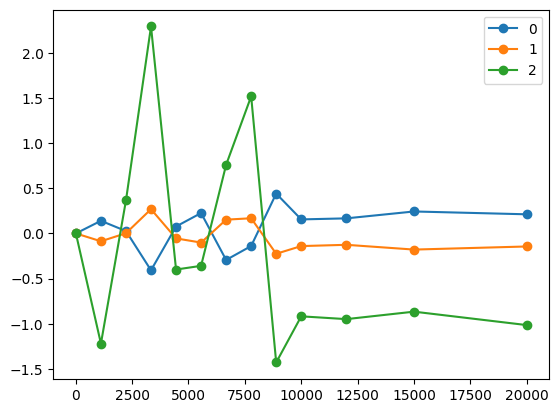

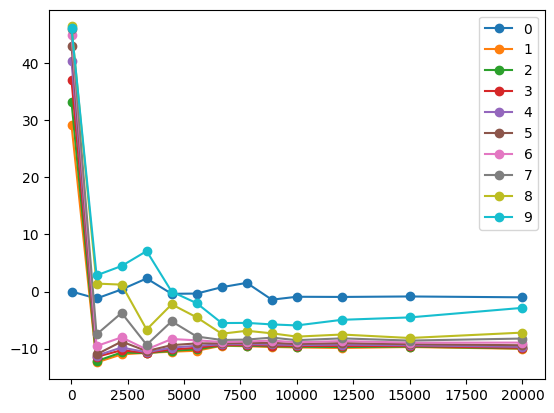

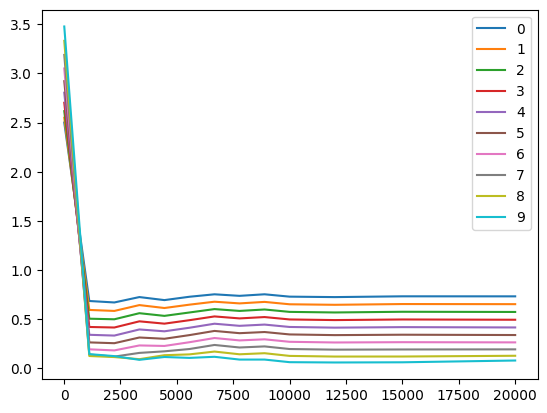

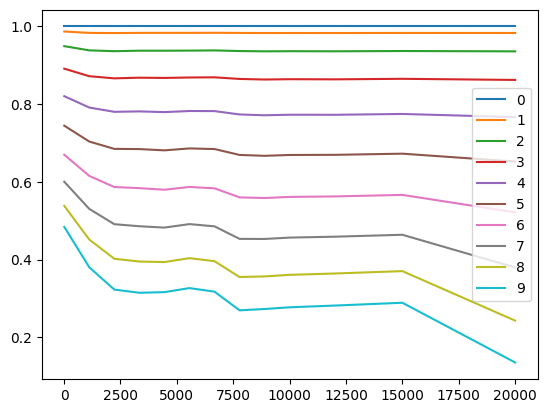

In [30]:
plt_nm = 3
# Ns = [10,50,100,500,1000,2500,5000,7500,10000]
all_gradients_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
all_loss_grid_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
all_metrics_mu_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid_3 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)

plt_nm = 2
# Ns = [10,50,100,500,1000,2500,5000,7500,10000]
all_gradients_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
all_loss_grid_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
all_metrics_mu_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid_2 = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)


print(np.shape(all_gradients_2))
print(np.shape(all_gradients_3))

all_gradients = np.concatenate([all_gradients_2,all_gradients_3],axis=0)
all_loss_grid = np.concatenate([all_loss_grid_2,all_loss_grid_3],axis=0)
Ns = np.concatenate([Ns_2,Ns_3],axis=0)
all_metrics_mu = np.concatenate([all_metrics_mu_2,all_metrics_mu_3])
all_metrics_Neff = np.concatenate([all_metrics_Neff_2,all_metrics_Neff_3])

print(np.shape(all_gradients))

import matplotlib.pyplot as plt

plt.figure()
print(Ns)
print(all_gradients[:,0,2])
for i in range(np.shape(all_gradients)[2]):
    plt.plot(Ns, -all_gradients[:,0,i],'-o', label=f'{i}')
plt.legend()

plt.figure()
for i in range(np.shape(all_gradients)[1]):
    plt.plot(Ns, -all_gradients[:,i,2],'-o', label=f'{i}')
plt.legend()

plt.figure()
print(Ns)
print(all_gradients[:,0,0])
for i in range(np.shape(all_loss_grid)[1]):
    plt.plot(Ns, all_loss_grid[:,i], label=f'{i}')
plt.legend()
print(np.shape(all_metrics_Neff))

plt.figure()
for i in range(np.shape(all_metrics_Neff)[1]):
    plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}')
plt.legend()



[12000 15000 20000]
[0.9481939  0.86561865 1.0142213 ]
[12000 15000 20000]
[-0.1667771  -0.24295811 -0.21157567]
(3, 10)


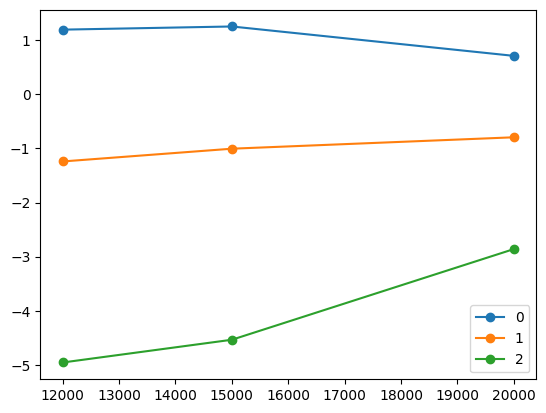

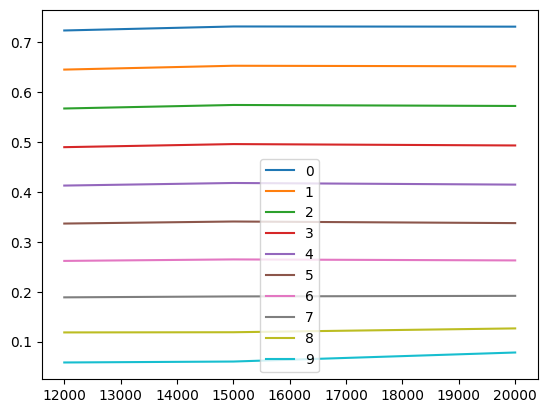

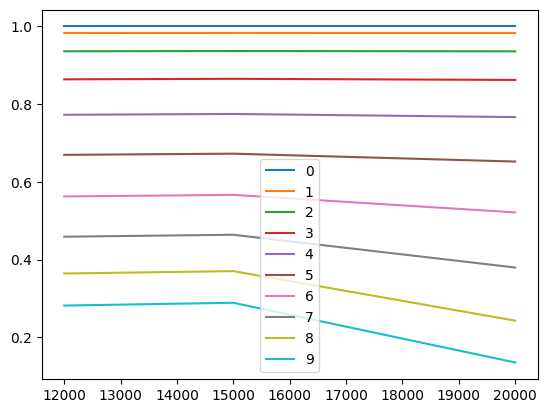

In [ ]:
# plt_nm = 3
# # Ns = [10,50,100,500,1000,2500,5000,7500,10000]
# all_gradients = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
# all_loss_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
# all_metrics_mu = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
# all_metrics_Neff = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
# Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
# line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)

# # plt.figure()
# # for i, gradients in enumerate(all_gradients):
# #     print(Ns[i], gradients[0,0])
# #     plt.scatter(Ns[i], gradients[0,0])

# # plt.show()
# import matplotlib.pyplot as plt

# plt.figure()
# print(Ns)
# print(all_gradients[:,0,2])
# for i in range(np.shape(all_gradients)[2]):
#     plt.plot(Ns, -all_gradients[:,9,i],'-o', label=f'{i}')
# plt.legend()

# plt.figure()
# print(Ns)
# print(all_gradients[:,0,0])
# for i in range(np.shape(all_loss_grid)[1]):
#     plt.plot(Ns, all_loss_grid[:,i], label=f'{i}')
# plt.legend()
# print(np.shape(all_metrics_Neff))

# plt.figure()
# for i in range(np.shape(all_metrics_Neff)[1]):
#     plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}')
# plt.legend()



[   10  1120  2230  3340  4450  5560  6670  7780  8890 10000 12000 15000
 20000]
[-0.          1.2188724  -0.36537778 -2.2899203   0.3994787   0.3585972
 -0.7590914  -1.5166197   1.4279006   0.91730356  0.9481939   0.86561865
  1.0142213 ]
[   10  1120  2230  3340  4450  5560  6670  7780  8890 10000 12000 15000
 20000]
[ 0.         -0.13970369 -0.02621874  0.40778726 -0.07656515 -0.22559506
  0.29346097  0.139339   -0.440856   -0.1551459  -0.1667771  -0.24295811
 -0.21157567]
(13, 10)


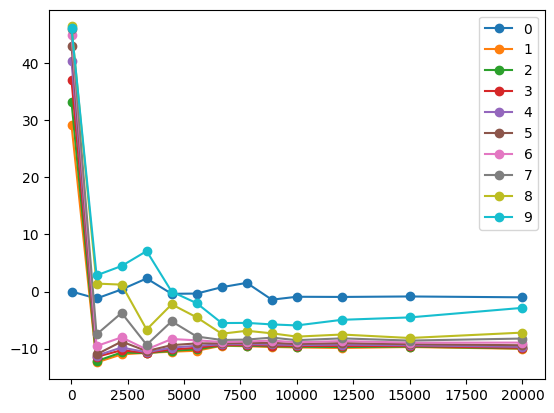

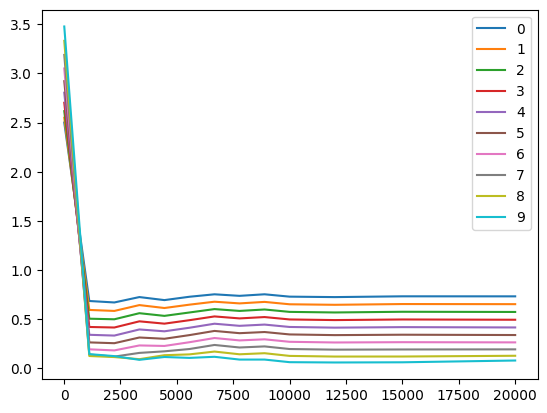

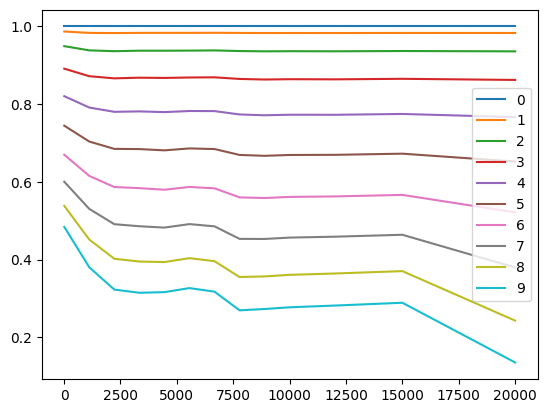

In [27]:

plt.figure()
print(Ns)
print(all_gradients[:,0,2])
for i in range(np.shape(all_gradients)[1]):
    plt.plot(Ns, -all_gradients[:,i,2],'-o', label=f'{i}')
# plt.yscale('log')
plt.legend()

plt.figure()
print(Ns)
print(all_gradients[:,0,0])
for i in range(np.shape(all_loss_grid)[1]):
    plt.plot(Ns, all_loss_grid[:,i], label=f'{i}')
plt.legend()
print(np.shape(all_metrics_Neff))

plt.figure()
for i in range(np.shape(all_metrics_Neff)[1]):
    plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}')
plt.legend()


10
1120
2230
3340
4450
5560
6670
7780
8890
10000
12000
15000
20000


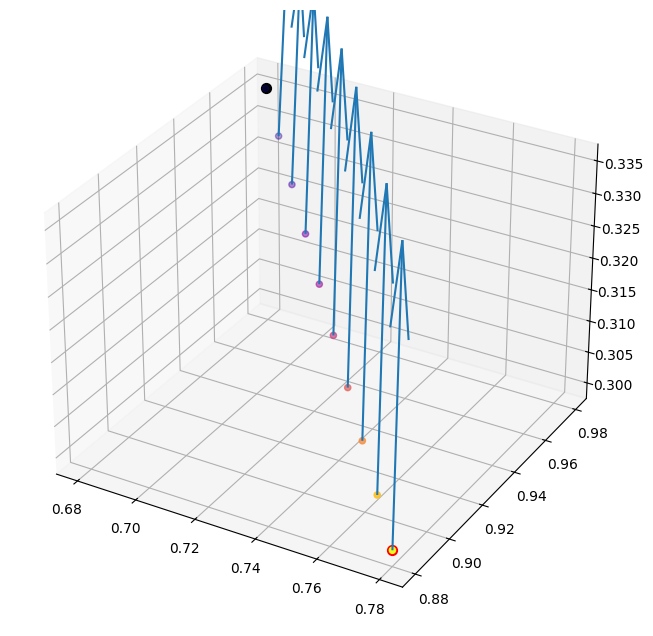

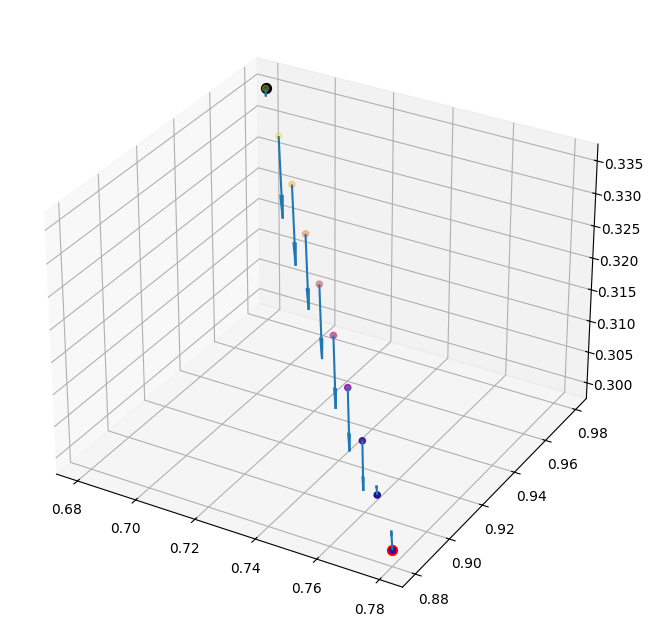

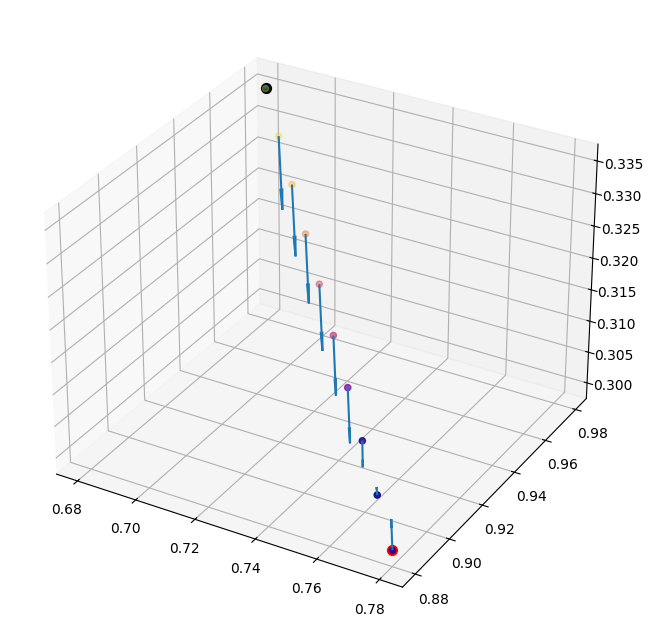

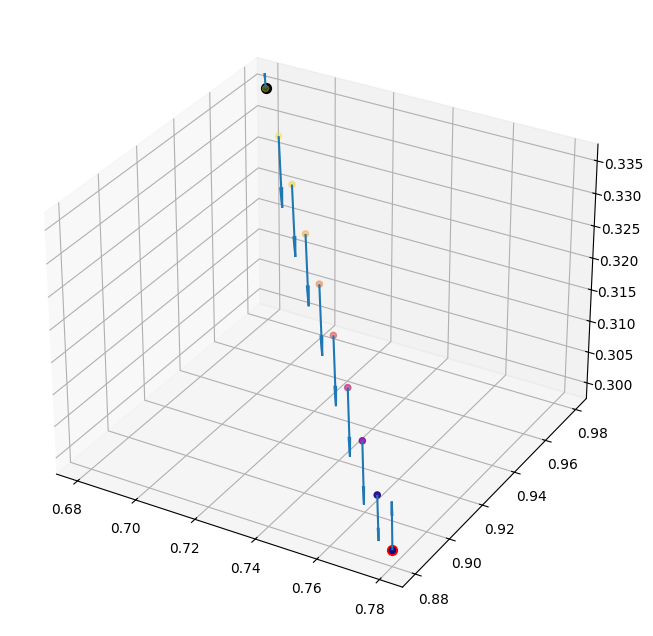

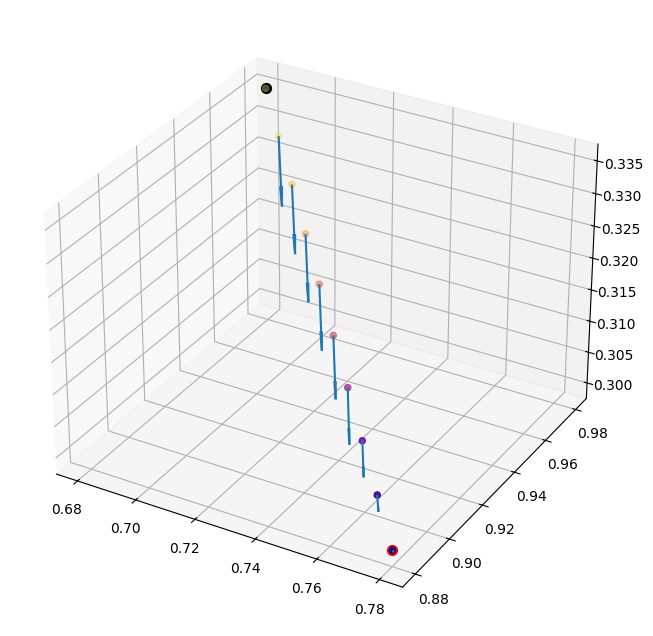

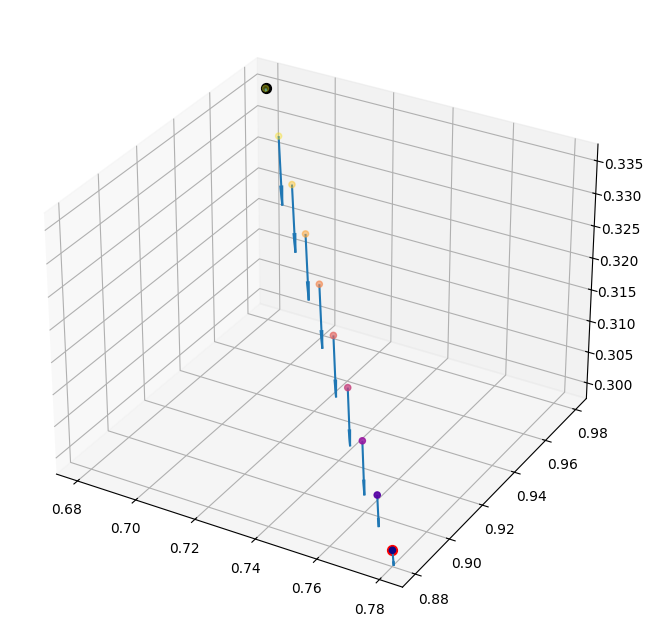

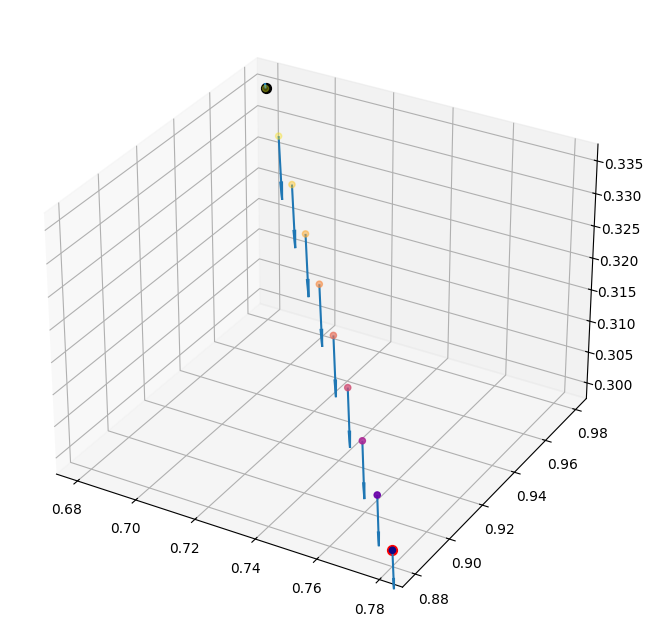

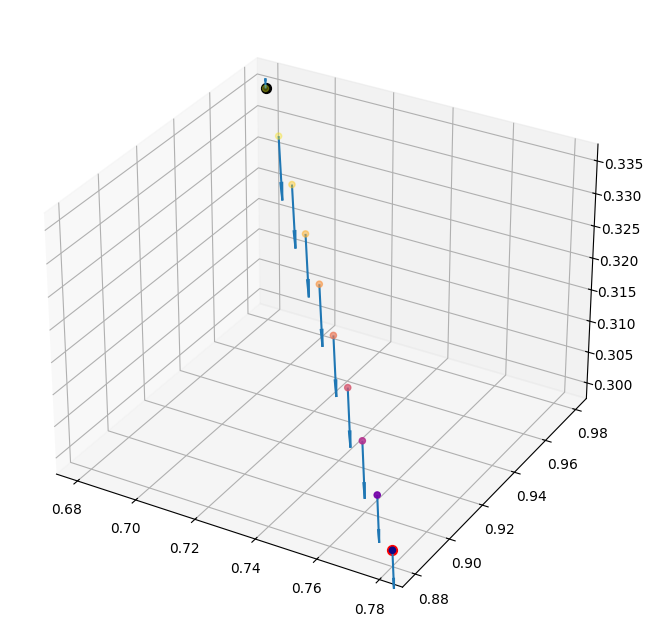

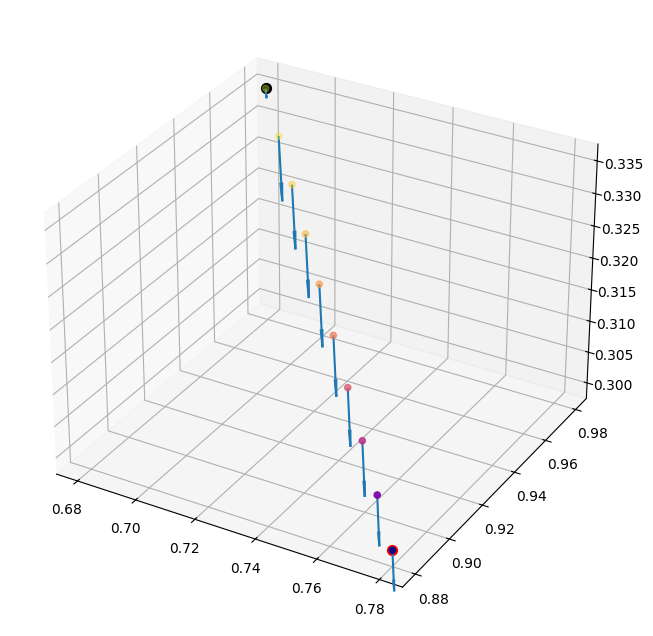

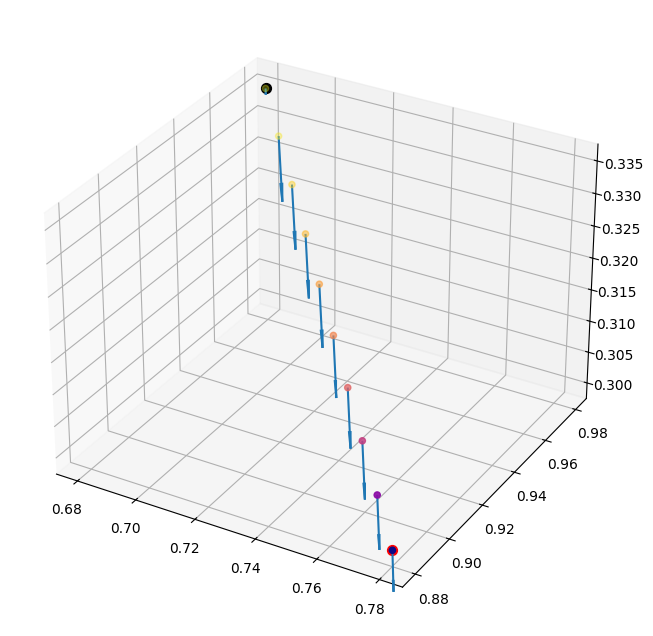

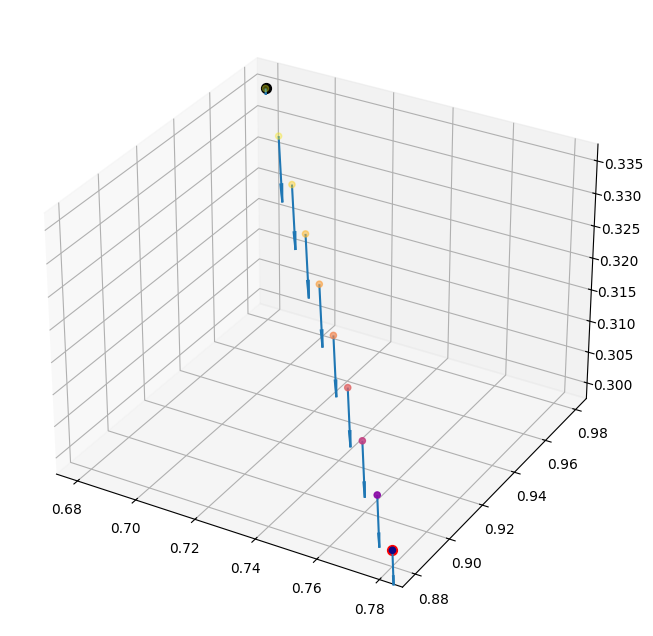

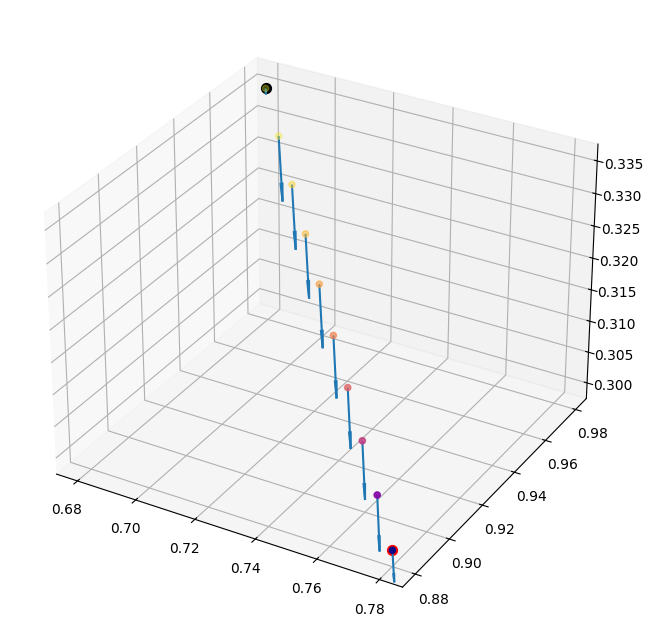

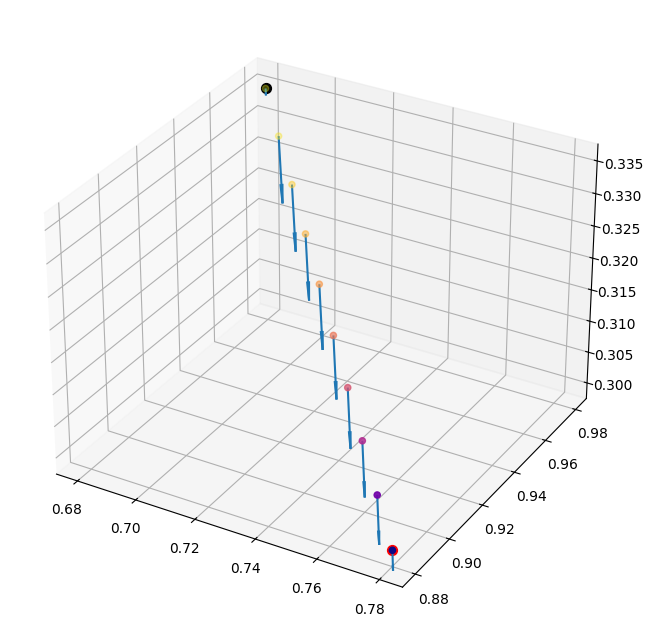

In [28]:
a_b_c = line_grid

for ind, N in enumerate(Ns):
    fig = plt.figure(figsize=(10, 8))
    print(N)
    a_b_gradients = all_gradients[ind]
    loss_grid = all_loss_grid[ind]


    ax = fig.add_subplot(111, projection='3d')

    ad = a_b_c[:,0]
    bd = a_b_c[:,1]
    sig = a_b_c[:,2]

    g1,g2,g3 =  -a_b_gradients[:,0], -a_b_gradients[:,1], -a_b_gradients[:,2],
    scale = 10e2
    ax.quiver(ad,bd,sig,g1/scale,g2/scale,g3/scale)
    # sc = ax.scatter(ad, bd, sig, c=magnitudes, cmap='plasma', s=20)  # 's' is size, 'c' is color
    sc = ax.scatter(ad, bd, sig, c=np.log10((loss_grid)), cmap='plasma', s=20)  # 's' is size, 'c' is color
    ax.scatter(0.68,0.98,0.335, label = 'base', c= 'black', s=50)
    ax.scatter(0.78,0.88,0.300, label = 'target', c='red', s=50)